# Kwantitatieve Evaluatie & Visuele Validatie – Dataset A

Evaluatie van de klassieke detectie- en trackingpipeline op de testset van dataset A.

**Metrieken:** Precision, Recall, F1-score, MOTA, MOTP, IDSW

**Evaluatienorm:** Een detectie is correct indien de Euclidische afstand tot de ground truth kleiner is dan 30 pixels (≈ gemiddelde radius van een loper in 4K-resolutie).

> **Vereisten:**
> - Video `Atletiekpiste.mp4` (zie `data/README.md`)
> - Ground truth JSON – gegenereerd via `1-Ground-Truth-Generatie.ipynb` (of gebruik de ingebouwde hardcoded data als fallback)
> - Bibliotheken: `opencv-python`, `numpy`, `pandas`, `matplotlib`, `scipy`, `motmetrics`

### Configuratie, Ground Truth Ingestie en Dataset-Partitionering

In [10]:
import cv2
import numpy as np
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from collections import OrderedDict
import motmetrics as mm

# Pad naar de video (pas aan indien nodig)
VIDEO_PATH = "../../data/video/Atletiekpiste.mp4"
GT_JSON_PATH = "../../data/ground_truth/dataset_A/ground_truth_atletiekpiste.json"

# HSV-drempelwaarden (getuned in tuning.ipynb)
LOWER_HSV = [140, 50, 50]
UPPER_HSV = [165, 255, 255]

# Fallback Ground Truth (hardcoded annotaties)
GT_INLINE = { 
    0: [[1503, 962], [1498, 1033], [1487, 1105], [1564, 1141], [1659, 1012], [1666, 1085], [1795, 1023], [1813, 1103]], 
    15: [[1557, 964], [1555, 1037], [1544, 1109], [1616, 1143], [1714, 1026], [1721, 1091], [1850, 1035], [1866, 1112]],
    30: [[1605, 964], [1603, 1037], [1596, 1111], [1662, 1148], [1768, 1030], [1768, 1093], [1900, 1030], [1909, 1109]], 
    45: [[1632, 973], [1628, 1041], [1625, 1114], [1691, 1161], [1791, 1041], [1791, 1100], [1925, 1041], [1931, 1118]], 
    60: [[1646, 980], [1646, 1050], [1639, 1127], [1705, 1170], [1795, 1057], [1804, 1113], [1936, 1061], [1943, 1138]], 
    75: [[1664, 986], [1662, 1061], [1650, 1138], [1718, 1181], [1807, 1070], [1816, 1131], [1947, 1066], [1954, 1143]], 
    90: [[1684, 995], [1687, 1070], [1671, 1145], [1736, 1195], [1823, 1070], [1832, 1140], [1965, 1075], [1974, 1158]], 
    105: [[1707, 1002], [1709, 1074], [1691, 1151], [1757, 1199], [1841, 1081], [1850, 1142], [1990, 1083], [1993, 1163]], 
    120: [[1718, 1008], [1718, 1081], [1705, 1165], [1761, 1201], [1854, 1097], [1857, 1151], [1999, 1088], [1999, 1172]], 
    135: [[1721, 1024], [1725, 1092], [1709, 1171], [1764, 1214], [1857, 1099], [1859, 1165], [2004, 1094], [1999, 1194]], 
    150: [[1727, 1024], [1734, 1096], [1711, 1169], [1764, 1219], [1859, 1096], [1868, 1164], [2004, 1096], [2002, 1192]], 
    165: [[1739, 1017], [1741, 1092], [1721, 1166], [1773, 1214], [1866, 1099], [1875, 1162], [2013, 1092], [2006, 1187]], 
    180: [[1752, 1021], [1752, 1098], [1734, 1166], [1779, 1225], [1877, 1092], [1888, 1173], [2024, 1105], [2020, 1193]], 
    195: [[1768, 1028], [1764, 1105], [1745, 1166], [1791, 1232], [1893, 1087], [1900, 1173], [2038, 1110], [2033, 1187]], 
    210: [[1775, 1026], [1775, 1100], [1755, 1164], [1798, 1225], [1909, 1093], [1906, 1166], [2047, 1107], [2042, 1182]], 
    225: [[1793, 1028], [1793, 1098], [1773, 1170], [1813, 1231], [1925, 1098], [1920, 1170], [2063, 1120], [2061, 1193]], 
    240: [[1813, 1034], [1811, 1102], [1795, 1177], [1832, 1238], [1945, 1109], [1938, 1179], [2083, 1125], [2083, 1195]], 
    255: [[1827, 1032], [1829, 1107], [1816, 1179], [1841, 1233], [1961, 1120], [1954, 1174], [2101, 1122], [2095, 1195]], 
    270: [[1843, 1034], [1843, 1109], [1834, 1179], [1854, 1233], [1972, 1120], [1970, 1181], [2117, 1127], [2104, 1199]], 
    285: [[1857, 1041], [1859, 1113], [1852, 1179], [1870, 1242], [1988, 1127], [1986, 1190], [2131, 1131], [2119, 1195]], 
    300: [[1875, 1052], [1877, 1126], [1872, 1185], [1884, 1258], [2006, 1140], [2006, 1201], [2147, 1131], [2142, 1206]], 
    315: [[1895, 1065], [1900, 1138], [1893, 1199], [1909, 1264], [2031, 1149], [2029, 1212], [2167, 1144], [2158, 1217]], 
    330: [[1922, 1072], [1925, 1149], [1915, 1208], [1934, 1278], [2054, 1158], [2054, 1226], [2187, 1142], [2185, 1221]], 
    345: [[1943, 1074], [1943, 1144], [1934, 1210], [1952, 1278], [2072, 1164], [2070, 1228], [2201, 1139], [2203, 1223]], 
    360: [[1959, 1074], [1963, 1144], [1952, 1209], [1965, 1273], [2088, 1157], [2085, 1225], [2217, 1142], [2217, 1219]], 
    375: [[1965, 1071], [1970, 1144], [1959, 1207], [1972, 1273], [2095, 1155], [2095, 1227], [2221, 1137], [2221, 1214]], 
    390: [[1968, 1078], [1972, 1148], [1961, 1216], [1977, 1286], [2095, 1166], [2092, 1234], [2224, 1146], [2226, 1232]], 
    405: [[1968, 1091], [1972, 1155], [1959, 1225], [1977, 1290], [2095, 1168], [2092, 1243], [2226, 1159], [2231, 1238]], 
    420: [[1972, 1098], [1974, 1159], [1963, 1225], [1983, 1293], [2099, 1173], [2095, 1243], [2224, 1159], [2233, 1240]], 
    435: [[1974, 1098], [1974, 1163], [1965, 1229], [1983, 1301], [2101, 1184], [2099, 1252], [2228, 1170], [2233, 1252]], 
    450: [[1979, 1104], [1979, 1165], [1970, 1233], [1988, 1306], [2104, 1181], [2106, 1261], [2235, 1181], [2237, 1249]], 
    465: [[1959, 1109], [1961, 1165], [1945, 1238], [1972, 1299], [2083, 1186], [2085, 1263], [2217, 1177], [2219, 1254]], 
    480: [[1920, 1111], [1922, 1170], [1909, 1238], [1936, 1308], [2047, 1197], [2049, 1265], [2183, 1183], [2185, 1267]], 
    495: [[1877, 1117], [1879, 1178], [1868, 1251], [1900, 1314], [2004, 1201], [2008, 1274], [2142, 1194], [2153, 1265]], 
    510: [[1838, 1131], [1841, 1183], [1825, 1253], [1863, 1310], [1968, 1205], [1970, 1280], [2108, 1196], [2119, 1276]], 
    525: [[1802, 1142], [1798, 1194], [1786, 1257], [1827, 1319], [1934, 1223], [1934, 1282], [2074, 1210], [2083, 1287]], 
    540: [[1766, 1135], [1764, 1203], [1748, 1266], [1791, 1323], [1897, 1223], [1900, 1284], [2042, 1214], [2051, 1280]], 
    555: [[1739, 1130], [1741, 1200], [1718, 1264], [1757, 1320], [1872, 1216], [1872, 1282], [2020, 1209], [2029, 1286]], 
    570: [[1718, 1141], [1725, 1205], [1698, 1266], [1745, 1318], [1850, 1221], [1854, 1284], [2004, 1221], [2008, 1291]], 
    585: [[1700, 1143], [1705, 1214], [1677, 1273], [1730, 1331], [1834, 1227], [1836, 1293], [1988, 1232], [1997, 1297]], 
    600: [[1682, 1148], [1687, 1223], [1662, 1277], [1709, 1338], [1813, 1229], [1818, 1302], [1970, 1236], [1986, 1315]], 
    615: [[1662, 1154], [1664, 1225], [1641, 1277], [1689, 1336], [1798, 1240], [1798, 1304], [1949, 1243], [1965, 1315]], 
    630: [[1639, 1154], [1648, 1215], [1623, 1274], [1659, 1333], [1775, 1240], [1773, 1299], [1931, 1245], [1940, 1320]], 
    645: [[1616, 1131], [1632, 1202], [1596, 1254], [1625, 1319], [1750, 1224], [1741, 1292], [1904, 1242], [1906, 1322]], 
    660: [[1598, 1109], [1614, 1181], [1575, 1226], [1600, 1294], [1730, 1210], [1718, 1278], [1877, 1238], [1884, 1303]], 
    675: [[1587, 1088], [1600, 1151], [1555, 1203], [1580, 1269], [1716, 1190], [1705, 1253], [1863, 1213], [1863, 1287]], 
    690: [[1578, 1065], [1587, 1133], [1544, 1194], [1566, 1255], [1707, 1169], [1696, 1233], [1852, 1192], [1850, 1269]], 
    705: [[1569, 1045], [1573, 1119], [1528, 1183], [1560, 1239], [1698, 1162], [1682, 1221], [1843, 1178], [1845, 1246]], 
    720: [[1553, 1031], [1562, 1099], [1514, 1158], [1555, 1219], [1689, 1149], [1668, 1203], [1834, 1158], [1832, 1232]], 
    735: [[1537, 1024], [1551, 1090], [1505, 1151], [1551, 1214], [1680, 1135], [1662, 1191], [1825, 1144], [1825, 1225]], 
    750: [[1528, 1015], [1539, 1087], [1498, 1151], [1546, 1214], [1673, 1132], [1657, 1187], [1823, 1144], [1823, 1209]], 
    765: [[1521, 1014], [1535, 1091], [1494, 1148], [1548, 1209], [1668, 1128], [1659, 1187], [1823, 1134], [1825, 1211]], 
    780: [[1517, 1026], [1535, 1096], [1496, 1157], [1551, 1216], [1668, 1116], [1664, 1184], [1827, 1125], [1829, 1200]], 
    795: [[1492, 1030], [1512, 1096], [1471, 1157], [1532, 1220], [1648, 1114], [1643, 1179], [1807, 1121], [1813, 1191]], 
    810: [[1467, 1023], [1485, 1098], [1446, 1152], [1501, 1209], [1625, 1111], [1619, 1175], [1789, 1109], [1793, 1193]], 
    825: [[1449, 1034], [1464, 1104], [1426, 1165], [1483, 1213], [1603, 1109], [1603, 1177], [1770, 1098], [1784, 1179]], 
    840: [[1442, 1048], [1453, 1113], [1417, 1177], [1473, 1226], [1591, 1118], [1589, 1179], [1764, 1097], [1779, 1177]], 
    855: [[1437, 1059], [1453, 1127], [1414, 1183], [1471, 1240], [1589, 1131], [1587, 1190], [1766, 1097], [1784, 1181]], 
    870: [[1451, 1043], [1469, 1124], [1421, 1179], [1478, 1228], [1596, 1117], [1594, 1185], [1779, 1097], [1798, 1176]], 
    885: [[1476, 1042], [1492, 1124], [1444, 1178], [1498, 1237], [1616, 1115], [1616, 1183], [1807, 1106], [1818, 1183]]
}

# Ground truth laden vanuit JSON; hardcoded data als fallback
if os.path.exists(GT_JSON_PATH):
    with open(GT_JSON_PATH, "r") as f:
        raw = json.load(f)
        ground_truth_data = {int(k): v for k, v in raw.items()}
        print(f"Ground truth geladen uit {GT_JSON_PATH}: {len(ground_truth_data)} frames.")
else:
    print(f"JSON niet gevonden. Hardcoded annotaties worden gebruikt.")
    ground_truth_data = GT_INLINE

# Splitsing: tuningset 20% (eerste 10 frames), testset 80% (resterende 50 frames)
all_frames = sorted(ground_truth_data.keys())
tuning_frames = all_frames[:10]
test_frames = all_frames[10:]

print(f"Tuningset: {len(tuning_frames)} frames | Testset: {len(test_frames)} frames")

Ground truth geladen uit ../../data/ground_truth/dataset_A/ground_truth_atletiekpiste.json: 60 frames.
Tuningset: 10 frames | Testset: 50 frames



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Klassen configureren

In [11]:
class RunnerDetector:
    """Klassieke HSV-gebaseerde detector voor lopers met magenta petjes."""
    def __init__(self, lower_hsv, upper_hsv, min_area=150, max_area=2000, min_aspect_ratio=0.5, max_aspect_ratio=2.0):
        self.lower_hsv = np.array(lower_hsv)
        self.upper_hsv = np.array(upper_hsv)
        self.min_area = min_area
        self.max_area = max_area
        self.min_aspect_ratio = min_aspect_ratio
        self.max_aspect_ratio = max_aspect_ratio

    def detect(self, frame):
        """
        Detecteert lopercentroïden in een BGR-frame via HSV-segmentatie.
        Returns
        -------
        tuple : (list of (x, y), np.ndarray binary mask)
        """
        blurred = cv2.GaussianBlur(frame, (5, 5), 0)
        hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, self.lower_hsv, self.upper_hsv)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=2)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        detections = []
        for cnt in contours:
            area = cv2.contourArea(cnt)
            if self.min_area < area < self.max_area:
                x, y, w, h = cv2.boundingRect(cnt)
                if self.min_aspect_ratio < float(w) / h < self.max_aspect_ratio:
                    detections.append((int(x + w / 2), int(y + h / 2)))
        return detections, mask

class CentroidTracker:
    """
    Eenvoudige centroid-tracker op basis van het Hongaarse algoritme.
    Koppelt detecies over opeenvolgende frames aan vaste tracker-IDs.
    """
    def __init__(self, max_disappeared=15, max_distance=60):
        self.next_id = 0
        self.objects = OrderedDict()
        self.disappeared = OrderedDict()
        self.max_disappeared = max_disappeared
        self.max_distance = max_distance

    def register(self, centroid):
        self.objects[self.next_id] = centroid
        self.disappeared[self.next_id] = 0
        self.next_id += 1

    def deregister(self, obj_id):
        del self.objects[obj_id]
        del self.disappeared[obj_id]

    def update(self, input_centroids):
        if not input_centroids:
            for obj_id in list(self.disappeared):
                self.disappeared[obj_id] += 1
                if self.disappeared[obj_id] > self.max_disappeared:
                    self.deregister(obj_id)
            return self.objects
            
        if not self.objects:
            for c in input_centroids:
                self.register(c)
            return self.objects
            
        obj_ids = list(self.objects.keys())
        obj_cents = list(self.objects.values())
        D = np.linalg.norm(
            np.array(obj_cents)[:, np.newaxis] - np.array(input_centroids),
            axis=2
        )
        
        rows, cols = linear_sum_assignment(D)
        used_rows, used_cols = set(), set()
        
        for row, col in zip(rows, cols):
            if row in used_rows or col in used_cols:
                continue
            if D[row, col] > self.max_distance:
                continue
                
            obj_id = obj_ids[row]
            self.objects[obj_id] = input_centroids[col]
            self.disappeared[obj_id] = 0
            used_rows.add(row)
            used_cols.add(col)
            
        for row in set(range(D.shape[0])) - used_rows:
            obj_id = obj_ids[row]
            self.disappeared[obj_id] += 1
            if self.disappeared[obj_id] > self.max_disappeared:
                self.deregister(obj_id)
                
        for col in set(range(D.shape[1])) - used_cols:
            self.register(input_centroids[col])
            
        return self.objects

class DetectionEvaluator:
    """Berekent Precision, Recall en F1-score over de testset."""
    def __init__(self, distance_threshold=30):
        self.threshold = distance_threshold
        self.tp = self.fp = self.fn = 0

    def update(self, detected, ground_truth):
        valid_gt = [p for p in ground_truth if p[0] != -1]
        
        if not valid_gt:
            self.fp += len(detected)
            return
        if not detected:
            self.fn += len(valid_gt)
            return
            
        dists = np.linalg.norm(
            np.array(detected)[:, None] - np.array(valid_gt)[None, :],
            axis=2
        )
        det_ind, gt_ind = linear_sum_assignment(dists)
        
        tp = sum(1 for di, gi in zip(det_ind, gt_ind) if dists[di, gi] < self.threshold)
        self.tp += tp
        self.fp += len(detected) - tp
        self.fn += len(valid_gt) - tp

    def metrics(self):
        prec = self.tp / (self.tp + self.fp) if (self.tp + self.fp) > 0 else 0.0
        rec = self.tp / (self.tp + self.fn) if (self.tp + self.fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        return prec, rec, f1

class TrackingEvaluator:
    """Berekent CLEAR MOT-metrieken (MOTA, MOTP, IDSW) via motmetrics."""
    def __init__(self):
        self.acc = mm.MOTAccumulator(auto_id=False)

    def update(self, frame_idx, gt_points, tracker_objects):
        gt_ids, gt_cents = [], []
        for gt_id, point in enumerate(gt_points):
            if point[0] != -1:
                gt_ids.append(gt_id)
                gt_cents.append(point)
                
        tr_ids = list(tracker_objects.keys())
        tr_cents = list(tracker_objects.values())
        
        dists = mm.distances.norm2squared_matrix(np.array(gt_cents), np.array(tr_cents))
        self.acc.update(frameid=frame_idx, oids=gt_ids, hids=tr_ids, dists=dists)

    def summary(self):
        mh = mm.metrics.create()
        return mh.compute(
            self.acc,
            metrics=["num_frames", "mota", "motp", "num_switches", "mostly_tracked", "mostly_lost"],
            name="full",
        ).rename(columns={"num_switches": "id_sw"})

print("Klassen geladen.")

Klassen geladen.


### Metrieken berekenen

In [12]:
detector = RunnerDetector(LOWER_HSV, UPPER_HSV)
det_eval = DetectionEvaluator()
tr_eval = TrackingEvaluator()
tracker = CentroidTracker(max_disappeared=15, max_distance=60)

cap = cv2.VideoCapture(VIDEO_PATH)

for frame_idx in test_frames:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    if not ret:
        break
        
    detections, _ = detector.detect(frame)
    det_eval.update(detections, ground_truth_data[frame_idx])
    
    active_tracks = tracker.update(detections)
    tr_eval.update(frame_idx, ground_truth_data[frame_idx], active_tracks)

cap.release()

# Detectiemetrieken
prec, rec, f1 = det_eval.metrics()
print("--- Detectie (statisch per frame) ---")
print(f"Precision : {prec:.2%}")
print(f"Recall    : {rec:.2%}")
print(f"F1-score  : {f1:.2%}")

# Trackingmetrieken
print("\n--- Tracking (temporeel, CLEAR MOT) ---")
print(tr_eval.summary().to_string())

--- Detectie (statisch per frame) ---
Precision : 100.00%
Recall    : 100.00%
F1-score  : 100.00%

--- Tracking (temporeel, CLEAR MOT) ---
      num_frames  mota  motp  id_sw  mostly_tracked  mostly_lost
full          50   1.0  3.89      0               8            0


### Visualisatie

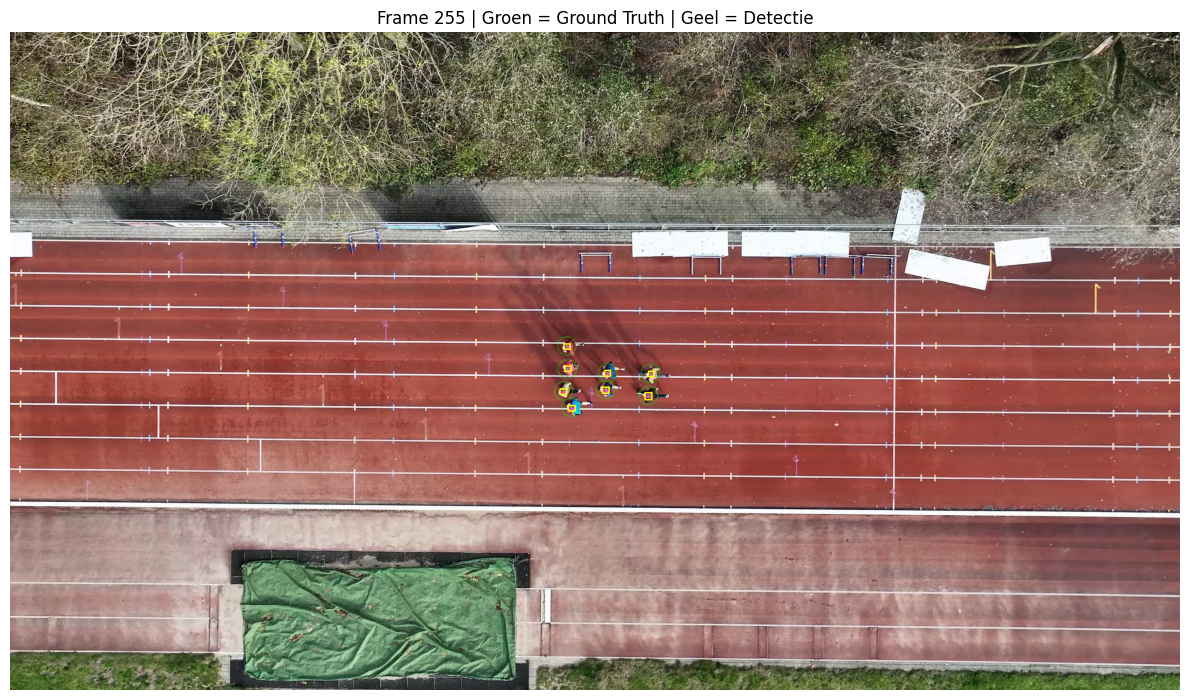

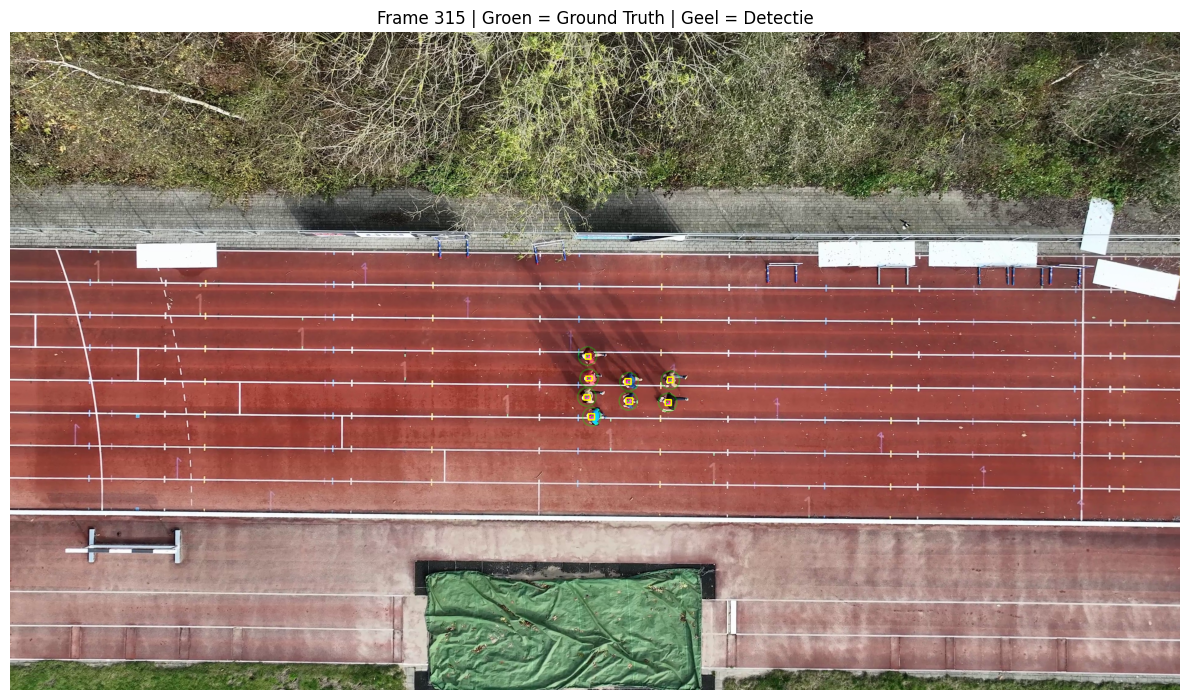

In [13]:
# Visualisatie van twee representatieve frames:
# Frame 255: optimaal detectieresultaat
# Frame 315: effect van false positives voor parametertuning (vóór optimalisatie)
FRAMES_TO_VISUALIZE = [255, 315]

cap = cv2.VideoCapture(VIDEO_PATH)

for fid in FRAMES_TO_VISUALIZE:
    cap.set(cv2.CAP_PROP_POS_FRAMES, fid)
    ret, frame = cap.read()
    
    if not ret:
        continue
        
    output_img = frame.copy()
    
    # Detectiepipeline
    blurred = cv2.GaussianBlur(frame, (5, 5), 0)
    hsv = cv2.cvtColor(blurred, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, detector.lower_hsv, detector.upper_hsv)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Gele bounding boxes voor de detecties van het algoritme
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if detector.min_area < area < detector.max_area:
            x, y, w, h = cv2.boundingRect(cnt)
            if detector.min_aspect_ratio < float(w) / h < detector.max_aspect_ratio:
                cv2.rectangle(output_img, (x, y), (x + w, y + h), (0, 255, 255), 4)
                
    # Groene cirkels voor de ground truth (semi-transparant)
    if fid in ground_truth_data:
        overlay = output_img.copy()
        THRESHOLD_PIXELS = 30
        for gt in ground_truth_data[fid]:
            if gt[0] != -1:
                cv2.circle(overlay, (gt[0], gt[1]), THRESHOLD_PIXELS, (0, 255, 0), 4)
                
        cv2.addWeighted(overlay, 0.3, output_img, 0.7, 0, output_img)
        
        for gt in ground_truth_data[fid]:
            if gt[0] != -1:
                cv2.circle(output_img, (gt[0], gt[1]), 3, (0, 255, 0), -1)
                
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {fid} | Groen = Ground Truth | Geel = Detectie")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

cap.release()